In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")  # Ignore warnings for cleaner output

# Set plotting style for better aesthetics
sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


## Accelerometer Data

In [ ]:
# Load the dataset from the CSV file
try:
    df = pd.read_sas('PAXMIN_H.xpt')
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Error: Make sure dataset is in the same directory as this notebook.")

# Display the first 5 rows to get a feel for the data
df.head()

In [ ]:
df = df[['SEQN','PAXDAYM','PAXDAYWM','PAXSSNMP','PAXMXM','PAXMXM','PAXMXM','PAXMTSM','PAXPREDM']]

In [ ]:
df.info()

In [ ]:
# Decode bytes columns
df['PAXDAYM'] = df['PAXDAYM'].str.decode('utf-8')
df['PAXDAYWM'] = df['PAXDAYWM'].str.decode('utf-8')
df['PAXPREDM'] = df['PAXPREDM'].str.decode('utf-8')

In [ ]:
type(df['PAXPREDM'].iloc[0])

In [ ]:
print("Unique values in 'PAXPREDM' BEFORE cleaning:", df['PAXPREDM'].unique())

In [ ]:
# Step 0: Exclude each participant's first recorded day
df = (
    df
    .sort_values(['SEQN', 'PAXDAYM'])
    .groupby('SEQN')
    .apply(lambda g: g[g['PAXDAYM'] != '1'])
    .reset_index(drop=True)
)

In [ ]:
# Sort data properly
df = df.sort_values(['SEQN','PAXDAYWM','PAXSSNMP']).copy()

# Compute difference between successive sample counts
df['delta_samples'] = df.groupby(['SEQN','PAXDAYWM'])['PAXSSNMP'].diff()

# Each minute = 4800 samples
SAMPLES_PER_MIN = 4800

# Minutes since start of day
df['minute_increment'] = (df['delta_samples'] / SAMPLES_PER_MIN).fillna(0)

# Cumulative minute count starting at 0:00
df['minute_of_day'] = df.groupby(['SEQN','PAXDAYWM'])['minute_increment'].cumsum().astype(int)

# Hour of day
df['hour_of_day'] = df['minute_of_day'] // 60

# Create time-of-day bins
df['time_period'] = pd.cut(
    df['hour_of_day'],
    bins=[-1, 4, 11, 16, 20, 23],
    labels=['night', 'morning', 'afternoon', 'evening', 'night_2'],
    right=True
)

# Merge the two night categories
df['time_period'] = df['time_period'].replace({'night_2': 'night'})

In [ ]:
# Remove rows with non wear or unknown wear
print("Rows in dataset BEFORE cleaning:", len(df))
print("Participants in dataset BEFORE cleaning:",df['SEQN'].nunique())
df_cleaned = df[(df['PAXPREDM'] == "1") | (df['PAXPREDM'] == "2")]
print("Unique values in 'PAXPREDM' AFTER cleaning:", df_cleaned['PAXPREDM'].unique())
print("Rows in dataset AFTER PAXPREDM cleaning:", len(df_cleaned))

# Remove rows with -0.01 value in PAXMTSM (value could not be computed)
df_cleaned = df_cleaned[df_cleaned['PAXMTSM'] != -0.01]

print("Rows in dataset AFTER PAXMTSM cleaning:", len(df_cleaned))
print("Participants in dataset AFTER cleaning:",df_cleaned['SEQN'].nunique())

In [ ]:
# Step 1: Filter out days with < 16 hours wear time
valid_days = (
    df_cleaned
    .groupby(['SEQN', 'PAXDAYM'])
    .filter(lambda g: len(g) >= 16 * 60)
)
# Step 2: Keep only participants with ≥ 4 valid days
final_df_cleaned = (
    valid_days
    .groupby('SEQN')
    .filter(lambda g: g['PAXDAYM'].nunique() >= 4)
)
print("Participants retained after filtering:", final_df_cleaned['SEQN'].nunique())

In [ ]:
print("Rows in dataset AFTER cleaning:", len(final_df_cleaned))

In [ ]:
print("Participants in dataset AFTER cleaning:",final_df_cleaned['SEQN'].nunique())

In [ ]:
final_df_cleaned.to_pickle('accelerometer_data_start.pkl')

## Load accelerometer data

In [2]:
final_df_cleaned = pd.read_pickle('accelerometer_data_start.pkl')

## Demographics Data

In [3]:
# Load the dataset from the CSV file
try:
    demo_df = pd.read_sas('DEMO_H.xpt')
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Error: Make sure dataset is in the same directory as this notebook.")

# Display the first 5 rows to get a feel for the data
demo_df.head()

Dataset loaded successfully!


,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,DMDHREDU,DMDHRMAR,DMDHSEDU,WTINT2YR,WTMEC2YR,SDMVPSU,SDMVSTRA,INDHHIN2,INDFMIN2,INDFMPIR
0,73557.0,8.0,2.0,1.0,69.0,NaN,4.0,4.0,1.0,NaN,...,3.0,4.0,NaN,13281.237386,13481.042095,1.0,112.0,4.0,4.0,0.84
1,73558.0,8.0,2.0,1.0,54.0,NaN,3.0,3.0,1.0,NaN,...,3.0,1.0,1.0,23682.057386,24471.769625,1.0,108.0,7.0,7.0,1.78
2,73559.0,8.0,2.0,1.0,72.0,NaN,3.0,3.0,2.0,NaN,...,4.0,1.0,3.0,57214.803319,57193.285376,1.0,109.0,10.0,10.0,4.51
3,73560.0,8.0,2.0,1.0,9.0,NaN,3.0,3.0,1.0,119.0,...,3.0,1.0,4.0,55201.178592,55766.512438,2.0,109.0,9.0,9.0,2.52
4,73561.0,8.0,2.0,2.0,73.0,NaN,3.0,3.0,1.0,NaN,...,5.0,1.0,5.0,63709.667069,65541.871229,2.0,116.0,15.0,15.0,5.00


In [4]:
print("Participants in dataset BEFORE cleaning:",demo_df['SEQN'].nunique())

Participants in dataset BEFORE cleaning: 10175


In [5]:
demo_df = demo_df[['SEQN','RIAGENDR','RIDAGEYR','RIDRETH3','DMDCITZN','DMDEDUC2','DMDMARTL','DMDHHSIZ','INDHHIN2','INDFMPIR']]

In [6]:
demo_df = demo_df.rename(columns={'RIAGENDR':"SEX",'RIDAGEYR':"AGE",'RIDRETH3':"RACE",'DMDCITZN':"CITIZENSHIP",'DMDEDUC2':"EDUCATION",'DMDMARTL':"MARITAL_STATUS",'DMDHHSIZ':"HH_NUMBER",'INDHHIN2':"HH_INCOME",'INDFMPIR':'RATIO_POVERTY'})
demo_df.head()

,SEQN,SEX,AGE,RACE,CITIZENSHIP,EDUCATION,MARITAL_STATUS,HH_NUMBER,HH_INCOME,RATIO_POVERTY
0,73557.0,1.0,69.0,4.0,1.0,3.0,4.0,3.0,4.0,0.84
1,73558.0,1.0,54.0,3.0,1.0,3.0,1.0,4.0,7.0,1.78
2,73559.0,1.0,72.0,3.0,1.0,4.0,1.0,2.0,10.0,4.51
3,73560.0,1.0,9.0,3.0,1.0,NaN,NaN,4.0,9.0,2.52
4,73561.0,2.0,73.0,3.0,1.0,5.0,1.0,2.0,15.0,5.00


In [7]:
demo_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10175 entries, 0 to 10174
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   SEQN            10175 non-null  float64
 1   SEX             10175 non-null  float64
 2   AGE             10175 non-null  float64
 3   RACE            10175 non-null  float64
 4   CITIZENSHIP     10171 non-null  float64
 5   EDUCATION       5769 non-null   float64
 6   MARITAL_STATUS  5769 non-null   float64
 7   HH_NUMBER       10175 non-null  float64
 8   HH_INCOME       10042 non-null  float64
 9   RATIO_POVERTY   9390 non-null   float64
dtypes: float64(10)
memory usage: 795.0 KB


In [8]:
# Remove rows with refusal, don't know, or missing values in citizenship
demo_df = demo_df[~demo_df['CITIZENSHIP'].isin([7, 9]) & demo_df['CITIZENSHIP'].notna()]
# Remove rows with refused or don't know marital status
demo_df = demo_df[~demo_df['MARITAL_STATUS'].isin([77, 99])]
# Remove rows with refused or don't know education
demo_df = demo_df[~demo_df['EDUCATION'].isin([7, 9]) & demo_df['EDUCATION'].notna()]
# Remove rows with refusal, don't know, or missing values in income
demo_df = demo_df[~demo_df['HH_INCOME'].isin([77, 99]) & demo_df['HH_INCOME'].notna()]
# Remove rows with mssing poverty ratio
demo_df = demo_df[demo_df['RATIO_POVERTY'].notna()]

In [9]:
demo_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5279 entries, 0 to 10172
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   SEQN            5279 non-null   float64
 1   SEX             5279 non-null   float64
 2   AGE             5279 non-null   float64
 3   RACE            5279 non-null   float64
 4   CITIZENSHIP     5279 non-null   float64
 5   EDUCATION       5279 non-null   float64
 6   MARITAL_STATUS  5279 non-null   float64
 7   HH_NUMBER       5279 non-null   float64
 8   HH_INCOME       5279 non-null   float64
 9   RATIO_POVERTY   5279 non-null   float64
dtypes: float64(10)
memory usage: 453.7 KB


In [10]:
# Only keep people 20+
demo_df = demo_df[demo_df['AGE'] >= 20]

In [11]:
print("Participants in dataset AFTER cleaning:",demo_df['SEQN'].nunique())

Participants in dataset AFTER cleaning: 5279


In [12]:
demo_df.to_csv('demographics_data.csv')

## Health Status Data

In [13]:
# Load the dataset from the CSV file
try:
    hsq_df = pd.read_sas('DPQ_H.xpt')
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Error: Make sure dataset is in the same directory as this notebook.")

# Display the first 5 rows to get a feel for the data
hsq_df.head()

Dataset loaded successfully!


,SEQN,DPQ010,DPQ020,DPQ030,DPQ040,DPQ050,DPQ060,DPQ070,DPQ080,DPQ090,DPQ100
0,73557.0,1.000000e+00,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,1.000000e+00
1,73558.0,2.000000e+00,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79
2,73559.0,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,NaN
3,73561.0,2.000000e+00,1.000000e+00,5.397605e-79,3.000000e+00,3.000000e+00,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,1.000000e+00
4,73562.0,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,1.000000e+00,2.000000e+00,1.000000e+00,5.397605e-79,3.000000e+00


In [14]:
print("Participants in dataset BEFORE cleaning:",hsq_df['SEQN'].nunique())

Participants in dataset BEFORE cleaning: 5924


In [15]:
hsq_df = hsq_df[['SEQN','DPQ010','DPQ020','DPQ030','DPQ040','DPQ050','DPQ060','DPQ070','DPQ080','DPQ090']]
# hsq_df = hsq_df.rename(columns={'DPQ010':'INTEREST','DPQ020':'DEPRESSED','DPQ030':'SLEEP_TROUBLE','DPQ040':'TIRED','DPQ050':'FOOD_TROUBLE','DPQ060':'POOR_SELF_IMAGE','DPQ090':'SUICIDAL_THOUGHTS','DPQ100':'LIFE_DIFFICULTY'})

In [16]:
hsq_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5924 entries, 0 to 5923
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SEQN    5924 non-null   float64
 1   DPQ010  5398 non-null   float64
 2   DPQ020  5396 non-null   float64
 3   DPQ030  5395 non-null   float64
 4   DPQ040  5395 non-null   float64
 5   DPQ050  5395 non-null   float64
 6   DPQ060  5394 non-null   float64
 7   DPQ070  5394 non-null   float64
 8   DPQ080  5394 non-null   float64
 9   DPQ090  5393 non-null   float64
dtypes: float64(10)
memory usage: 462.9 KB


In [17]:
# Remove refused, don't know and missing
hsq_df = hsq_df[~hsq_df['DPQ010'].isin([7, 9]) & hsq_df['DPQ020'].notna()]
hsq_df = hsq_df[~hsq_df['DPQ020'].isin([7, 9]) & hsq_df['DPQ020'].notna()]
hsq_df = hsq_df[~hsq_df['DPQ030'].isin([7, 9]) & hsq_df['DPQ030'].notna()]
hsq_df = hsq_df[~hsq_df['DPQ040'].isin([7, 9]) & hsq_df['DPQ040'].notna()]
hsq_df = hsq_df[~hsq_df['DPQ050'].isin([7, 9]) & hsq_df['DPQ050'].notna()]
hsq_df = hsq_df[~hsq_df['DPQ060'].isin([7, 9]) & hsq_df['DPQ060'].notna()]
hsq_df = hsq_df[~hsq_df['DPQ070'].isin([7, 9]) & hsq_df['DPQ070'].notna()]
hsq_df = hsq_df[~hsq_df['DPQ080'].isin([7, 9]) & hsq_df['DPQ080'].notna()]
hsq_df = hsq_df[~hsq_df['DPQ090'].isin([7, 9]) & hsq_df['DPQ090'].notna()]

In [18]:
print("Participants in dataset AFTER cleaning:",hsq_df['SEQN'].nunique())

Participants in dataset AFTER cleaning: 5372


In [19]:
hsq_df['Total_Depression_Score'] = (hsq_df['DPQ010'] + hsq_df['DPQ020'] + hsq_df['DPQ030'] + hsq_df['DPQ040'] +
                                   hsq_df['DPQ050'] + hsq_df['DPQ060'] + hsq_df['DPQ070'] + hsq_df['DPQ080'] + hsq_df['DPQ090'])

In [20]:
demo_df = demo_df.merge(hsq_df[['SEQN', 'Total_Depression_Score']], on='SEQN', how='left')
demo_df.head()

,SEQN,SEX,AGE,RACE,CITIZENSHIP,EDUCATION,MARITAL_STATUS,HH_NUMBER,HH_INCOME,RATIO_POVERTY,Total_Depression_Score
0,73557.0,1.0,69.0,4.0,1.0,3.0,4.0,3.0,4.0,0.84,1.000000e+00
1,73558.0,1.0,54.0,3.0,1.0,3.0,1.0,4.0,7.0,1.78,2.000000e+00
2,73559.0,1.0,72.0,3.0,1.0,4.0,1.0,2.0,10.0,4.51,4.857845e-78
3,73561.0,2.0,73.0,3.0,1.0,5.0,1.0,2.0,15.0,5.00,9.000000e+00
4,73562.0,1.0,56.0,1.0,1.0,4.0,3.0,1.0,9.0,4.79,1.900000e+01


In [21]:
# drop nan rows
demo_df = demo_df.dropna()

In [22]:
print("Participants in dataset AFTER cleaning:",demo_df['SEQN'].nunique())

Participants in dataset AFTER cleaning: 4667


In [23]:
# Resave demographics
demo_df.to_csv('demographics_data.csv')

## Reduce datasets

In [24]:
# Check for fully duplicated rows in accelerometer
total_duplicates = final_df_cleaned.duplicated().sum()
print(f"Total fully duplicated rows: {total_duplicates}")

# # Check for duplicates based on interview identifiers, as done in the report [cite: 1079]
# # Note: The report uses "No_Pation" but the CSV has "No_Pation". We'll use the correct column name.
# interview_duplicates = final_df_cleaned.duplicated(subset=["ADM_RNO1"]).sum()
# print(f"Rows with the same interviewee: {interview_duplicates}")

Total fully duplicated rows: 0


In [25]:
# Check for fully duplicated rows in demographics
total_duplicates = demo_df.duplicated().sum()
print(f"Total fully duplicated rows: {total_duplicates}")

# Check for duplicates based on survey id number
survey_duplicates = demo_df.duplicated(subset=["SEQN"]).sum()
print(f"Rows with the same participant: {survey_duplicates}")

Total fully duplicated rows: 0
Rows with the same participant: 0


In [26]:
# Convert to sets and get intersection
df_parts = final_df_cleaned['SEQN'].unique()
demo_parts = demo_df['SEQN'].unique()

common_values = set(df_parts) & set(demo_parts)

print(len(common_values))

3701


In [27]:
final_accel_df = final_df_cleaned[final_df_cleaned['SEQN'].isin(common_values)]
final_demo_df = demo_df[demo_df['SEQN'].isin(common_values)]

In [28]:
final_demo_df = demo_df[demo_df['SEQN'].isin(common_values)]

In [29]:
final_accel_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 34140496 entries, 18280 to 84356632
Data columns (total 14 columns):
 #   Column            Dtype   
---  ------            -----   
 0   SEQN              float64 
 1   PAXDAYM           object  
 2   PAXDAYWM          object  
 3   PAXSSNMP          float64 
 4   PAXMXM            float64 
 5   PAXMXM            float64 
 6   PAXMXM            float64 
 7   PAXMTSM           float64 
 8   PAXPREDM          object  
 9   delta_samples     float64 
 10  minute_increment  float64 
 11  minute_of_day     int64   
 12  hour_of_day       int64   
 13  time_period       category
dtypes: category(1), float64(8), int64(2), object(3)
memory usage: 3.6+ GB


In [30]:
final_accel_df['SEQN'].nunique()

3701

In [31]:
final_demo_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3701 entries, 1 to 5276
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   SEQN                    3701 non-null   float64
 1   SEX                     3701 non-null   float64
 2   AGE                     3701 non-null   float64
 3   RACE                    3701 non-null   float64
 4   CITIZENSHIP             3701 non-null   float64
 5   EDUCATION               3701 non-null   float64
 6   MARITAL_STATUS          3701 non-null   float64
 7   HH_NUMBER               3701 non-null   float64
 8   HH_INCOME               3701 non-null   float64
 9   RATIO_POVERTY           3701 non-null   float64
 10  Total_Depression_Score  3701 non-null   float64
dtypes: float64(11)
memory usage: 347.0 KB


In [32]:
# Save the final dataframes
final_demo_df.to_csv('demographics_data.csv')
final_accel_df.to_pickle('accelerometer_data.pkl')

In [33]:
len(final_demo_df[final_demo_df['Total_Depression_Score'] >= 10])

359

In [34]:
hsq_df.head()

,SEQN,DPQ010,DPQ020,DPQ030,DPQ040,DPQ050,DPQ060,DPQ070,DPQ080,DPQ090,Total_Depression_Score
0,73557.0,1.000000e+00,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,1.000000e+00
1,73558.0,2.000000e+00,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,2.000000e+00
2,73559.0,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,4.857845e-78
3,73561.0,2.000000e+00,1.000000e+00,5.397605e-79,3.000000e+00,3.000000e+00,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,9.000000e+00
4,73562.0,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,1.000000e+00,2.000000e+00,1.000000e+00,5.397605e-79,1.900000e+01


## Accelerometer Features

### Physical Activity

In [35]:
final_accel_df = pd.read_pickle('accelerometer_data.pkl')

In [36]:
# For each row in the accelerometer dataset include if it is
# sedentary, light, mod, vigorous

# Sedentary: < 4 MIMS/min

# Light activity: 4–10 MIMS/min

# Moderate activity: 10–20 MIMS/min

# Vigorous activity: > 20 MIMS/min

conditions = [
    final_accel_df['PAXMTSM'] < 10.6,
    (final_accel_df['PAXMTSM'] >= 10.6) & (final_accel_df['PAXMTSM'] < 19.6),
    (final_accel_df['PAXMTSM'] >= 19.6) ]

choices = ['Sedentary', 'Light', 'Moderate']

final_accel_df['ACTIVITY'] = np.select(conditions, choices, default=None)

In [37]:
# Keep only valid wear
df = final_accel_df[final_accel_df['PAXPREDM'] == '1']

# Count minutes per day per activity
daily_activity = (
    df.groupby(['SEQN', 'PAXDAYM', 'ACTIVITY'])
      .size()
      .reset_index(name='minutes')
)

# Now compute average minutes per day per activity per participant
avg_daily_activity = (
    daily_activity.groupby(['SEQN', 'ACTIVITY'])['minutes']
                  .mean()
                  .reset_index(name='avg_daily_minutes')
)

In [38]:
daily_activity

,SEQN,PAXDAYM,ACTIVITY,minutes
0,73558.0,2,Light,220
1,73558.0,2,Moderate,265
2,73558.0,2,Sedentary,403
3,73558.0,3,Light,197
4,73558.0,3,Moderate,135
...,...,...,...,...
75140,83724.0,7,Moderate,216
75141,83724.0,7,Sedentary,444
75142,83724.0,8,Light,286
75143,83724.0,8,Moderate,200


In [39]:
avg_daily_activity

,SEQN,ACTIVITY,avg_daily_minutes
0,73558.0,Light,195.571429
1,73558.0,Moderate,187.285714
2,73558.0,Sedentary,474.285714
3,73559.0,Light,145.285714
4,73559.0,Moderate,188.142857
...,...,...,...
11095,83723.0,Moderate,221.500000
11096,83723.0,Sedentary,446.833333
11097,83724.0,Light,244.000000
11098,83724.0,Moderate,200.428571


In [40]:
# Calculate avg wake wear MIMS for each participant
# First compute daily averages
daily_avg = final_accel_df[final_accel_df['PAXPREDM'] == '1'].groupby(['SEQN','PAXDAYM'])['PAXMTSM'].mean().reset_index(name='DAILY_MEAN_MIMS')

# Then average across days per participant
avg_daily_mims = daily_avg.groupby('SEQN')['DAILY_MEAN_MIMS'].mean().reset_index()

In [41]:
# Peak 30 MIMS
df_wake = final_accel_df[final_accel_df['PAXPREDM'] == '1'].copy()
daily_peak30 = (
    df_wake
    .groupby(['SEQN', 'PAXDAYM'])['PAXMTSM']
    .apply(lambda x: x.nlargest(30).sum())
    .reset_index(name='DAILY_PEAK30_MIMS')
)
avg_peak30_mims = (
    daily_peak30.groupby('SEQN')['DAILY_PEAK30_MIMS']
    .mean()
    .reset_index(name='AVG_PEAK30_MIMS')
)

In [42]:
activity_summary = (
    df_wake.groupby(['SEQN','PAXDAYM','time_period'])['PAXMTSM']
    .mean()
    .reset_index(name='avg_mims')
)

In [43]:
import itertools

# Compute total avg daily MIMS per participant
daily_total = (
    activity_summary.groupby(['SEQN','PAXDAYM'])['avg_mims']
    .sum()
    .reset_index(name='daily_total_mims')
)

# Merge with activity_summary
activity_norm = activity_summary.merge(daily_total, on=['SEQN','PAXDAYM'])

# Compute proportion of MIMS per time period
activity_norm['mims_fraction'] = activity_norm['avg_mims'] / activity_norm['daily_total_mims']

# Now you can average across days for each participant and time period
participant_summary = (
    activity_norm.groupby(['SEQN','time_period'])['mims_fraction']
    .mean()
    .reset_index()
)

# All unique participants and time periods
participants = activity_norm['SEQN'].unique()
time_periods = activity_norm['time_period'].unique()

# Create all possible combinations
all_combinations = pd.DataFrame(list(itertools.product(participants, time_periods)), columns=['SEQN','time_period'])

# Merge with your computed participant_summary
participant_summary = all_combinations.merge(participant_summary, on=['SEQN','time_period'], how='left')

# Fill missing fractions with 0
participant_summary['mims_fraction'] = participant_summary['mims_fraction'].fillna(0)

participant_summary

,SEQN,time_period,mims_fraction
0,73558.0,night,0.176474
1,73558.0,morning,0.267708
2,73558.0,afternoon,0.273566
3,73558.0,evening,0.282252
4,73559.0,night,0.196716
...,...,...,...
14795,83723.0,evening,0.239921
14796,83724.0,night,0.257436
14797,83724.0,morning,0.288342
14798,83724.0,afternoon,0.211782


In [44]:
participant_summary

,SEQN,time_period,mims_fraction
0,73558.0,night,0.176474
1,73558.0,morning,0.267708
2,73558.0,afternoon,0.273566
3,73558.0,evening,0.282252
4,73559.0,night,0.196716
...,...,...,...
14795,83723.0,evening,0.239921
14796,83724.0,night,0.257436
14797,83724.0,morning,0.288342
14798,83724.0,afternoon,0.211782


### Sleep

In [45]:
# Filter sleep minutes
sleep_minutes = final_accel_df[final_accel_df['PAXPREDM'] == '2']

# Daily sleep duration (in minutes)
daily_sleep = (
    sleep_minutes.groupby(['SEQN', 'PAXDAYM'])['PAXMTSM']
    .count()
    .reset_index(name='SLEEP_DURATION_MIN')
)

# Average sleep duration per participant
avg_sleep_duration = (
    daily_sleep.groupby('SEQN')['SLEEP_DURATION_MIN']
    .mean()
    .reset_index(name='AVG_SLEEP_DURATION_MIN')
)

# Sleep duration variability per participant (standard deviation)
sleep_variability = (
    daily_sleep.groupby('SEQN')['SLEEP_DURATION_MIN']
    .std()
    .reset_index(name='SLEEP_DURATION_SD')
)

# Merge into one dataframe
sleep_summary = avg_sleep_duration.merge(sleep_variability, on='SEQN')

sleep_summary['AVG_SLEEP_HOURS'] = sleep_summary['AVG_SLEEP_DURATION_MIN'] / 60
sleep_summary['SLEEP_SD_HOURS'] = sleep_summary['SLEEP_DURATION_SD'] / 60

sleep_summary.head()

,SEQN,AVG_SLEEP_DURATION_MIN,SLEEP_DURATION_SD,AVG_SLEEP_HOURS,SLEEP_SD_HOURS
0,73558.0,488.285714,95.616795,8.138095,1.593613
1,73559.0,572.142857,55.185833,9.535714,0.919764
2,73561.0,552.285714,35.915244,9.204762,0.598587
3,73562.0,413.500000,164.532237,6.891667,2.742204
4,73564.0,567.571429,71.198917,9.459524,1.186649


In [46]:
df_sleep = final_accel_df[(final_accel_df['time_period'] == 'evening') | (final_accel_df['time_period'] == 'night') | (final_accel_df['time_period'] == 'morning')].copy()
df_sleep['sleeping'] = df_sleep['PAXPREDM'].astype(str) == '2'

In [47]:
from skdh.sleep import NumberWakeBouts

# Convert day column to integer if needed
df_sleep['PAXDAYM'] = df_sleep['PAXDAYM'].astype(int)

# Prepare output list
sleep_summary_list = []

# Loop over participants
for pid, df_pid in df_sleep.groupby('SEQN'):
    # Loop over days
    for day, df_day in df_pid.groupby('PAXDAYM'):
        # scikit-digital-health expects 1D activity vector
        # We'll use triaxial magnitude or a single axis
        # Here, we can use the total MIMS (PAXMTSM)
        activity = df_day['sleeping'].to_numpy()

        # Compute Number of Wake Bouts
        wake_bouts = NumberWakeBouts().predict(activity)
        
        sleep_summary_list.append({
            'SEQN': pid,
            'PAXDAYM': day,
            'wake_bouts': wake_bouts
        })

# Convert to dataframe
sleep_day_df = pd.DataFrame(sleep_summary_list)

# --- Compute per-participant averages and variability ---

participant_sleep_summary = (
    sleep_day_df.groupby('SEQN')
    .agg(
        avg_wake_bouts=('wake_bouts', 'mean')
    )
    .reset_index()
)

sleep_summary['Avg_wake_bouts'] = participant_sleep_summary['avg_wake_bouts']

print(sleep_summary.head())

      SEQN  AVG_SLEEP_DURATION_MIN  SLEEP_DURATION_SD  AVG_SLEEP_HOURS  \
0  73558.0              488.285714          95.616795         8.138095   
1  73559.0              572.142857          55.185833         9.535714   
2  73561.0              552.285714          35.915244         9.204762   
3  73562.0              413.500000         164.532237         6.891667   
4  73564.0              567.571429          71.198917         9.459524   

   SLEEP_SD_HOURS  Avg_wake_bouts  
0        1.593613        8.142857  
1        0.919764        6.142857  
2        0.598587       10.428571  
3        2.742204        7.714286  
4        1.186649        8.714286  


In [48]:
participant_summary

,SEQN,time_period,mims_fraction
0,73558.0,night,0.176474
1,73558.0,morning,0.267708
2,73558.0,afternoon,0.273566
3,73558.0,evening,0.282252
4,73559.0,night,0.196716
...,...,...,...
14795,83723.0,evening,0.239921
14796,83724.0,night,0.257436
14797,83724.0,morning,0.288342
14798,83724.0,afternoon,0.211782


In [49]:
activity_wide = avg_daily_activity.pivot(index='SEQN', columns='ACTIVITY', values='avg_daily_minutes').reset_index()
activity_period_wide = participant_summary.pivot(index='SEQN', columns='time_period', values='mims_fraction').reset_index()

# Merge with average daily MIMS and peak 30 daily MIMS
summary = activity_wide.merge(avg_daily_mims, on='SEQN')
summary = summary.merge(activity_period_wide, on='SEQN')
summary = summary.merge(avg_peak30_mims, on='SEQN')

# Merge sleep time
summary = summary.merge(sleep_summary, on='SEQN')

In [50]:
# Merge with demographics
summary_demo_df = final_demo_df.merge(summary, on='SEQN')

In [51]:
summary_demo_df

,SEQN,SEX,AGE,RACE,CITIZENSHIP,EDUCATION,MARITAL_STATUS,HH_NUMBER,HH_INCOME,RATIO_POVERTY,...,afternoon,evening,morning,night,AVG_PEAK30_MIMS,AVG_SLEEP_DURATION_MIN,SLEEP_DURATION_SD,AVG_SLEEP_HOURS,SLEEP_SD_HOURS,Avg_wake_bouts
0,73558.0,1.0,54.0,3.0,1.0,3.0,1.0,4.0,7.0,1.78,...,0.273566,0.282252,0.267708,0.176474,1094.748857,488.285714,95.616795,8.138095,1.593613,8.142857
1,73559.0,1.0,72.0,3.0,1.0,4.0,1.0,2.0,10.0,4.51,...,0.247509,0.187611,0.368163,0.196716,1171.340857,572.142857,55.185833,9.535714,0.919764,6.142857
2,73561.0,2.0,73.0,3.0,1.0,5.0,1.0,2.0,15.0,5.00,...,0.249400,0.269674,0.277101,0.203824,961.653000,552.285714,35.915244,9.204762,0.598587,10.428571
3,73562.0,1.0,56.0,1.0,1.0,4.0,3.0,1.0,9.0,4.79,...,0.223509,0.186270,0.332937,0.257284,1335.521125,413.500000,164.532237,6.891667,2.742204,7.714286
4,73564.0,2.0,61.0,3.0,1.0,5.0,2.0,1.0,10.0,5.00,...,0.291538,0.221959,0.319350,0.167153,1117.778857,567.571429,71.198917,9.459524,1.186649,8.714286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3695,83711.0,2.0,38.0,3.0,1.0,3.0,1.0,7.0,7.0,1.08,...,0.261789,0.282538,0.239609,0.216064,1208.413429,490.142857,31.997024,8.169048,0.533284,7.285714
3696,83712.0,1.0,61.0,3.0,1.0,2.0,1.0,5.0,9.0,2.04,...,0.195665,0.266411,0.283682,0.254242,1250.497571,277.142857,147.921633,4.619048,2.465361,3.571429
3697,83717.0,2.0,80.0,1.0,2.0,1.0,2.0,7.0,6.0,0.70,...,0.296285,0.267084,0.238055,0.198576,1076.075143,557.571429,106.007637,9.292857,1.766794,5.571429
3698,83723.0,1.0,61.0,1.0,1.0,2.0,1.0,3.0,10.0,3.53,...,0.278094,0.239921,0.292299,0.189686,1048.653833,416.833333,37.520217,6.947222,0.625337,6.333333


In [52]:
summary_demo_df = summary_demo_df.dropna()

In [53]:
len(summary_demo_df)

3700

In [54]:
# Save the final dataframes
summary_demo_df.to_csv('demographics_data.csv')
final_accel_df.to_pickle('accelerometer_data.pkl')

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('demographics_data.csv')

In [56]:
df['Depression_Category'] = df["Total_Depression_Score"].apply(lambda x: 1 if x >= 10 else 0)

In [57]:
sensitive_features = ['SEX', 'AGE', 'RACE', 'CITIZENSHIP', 'EDUCATION', 'MARITAL_STATUS','HH_NUMBER', 'HH_INCOME', 'RATIO_POVERTY']

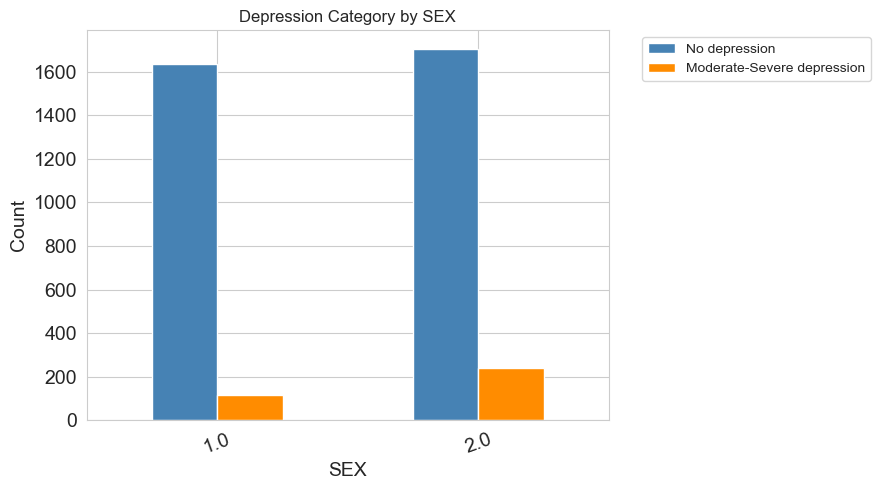

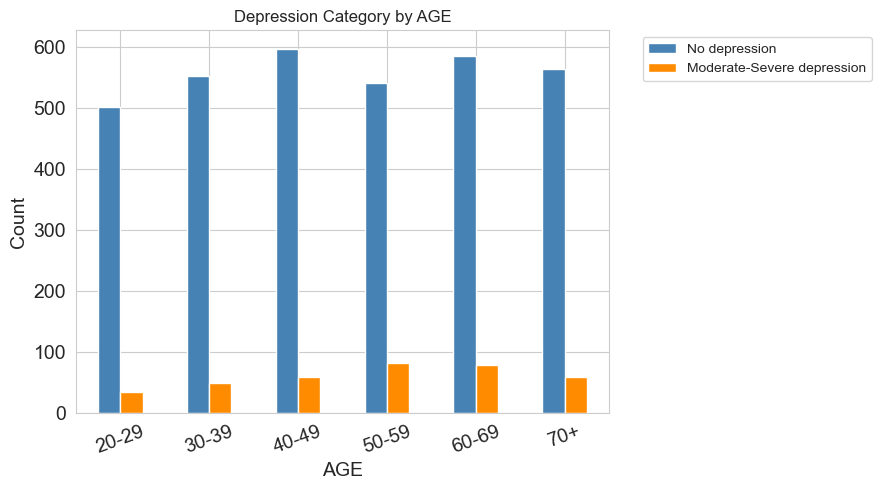

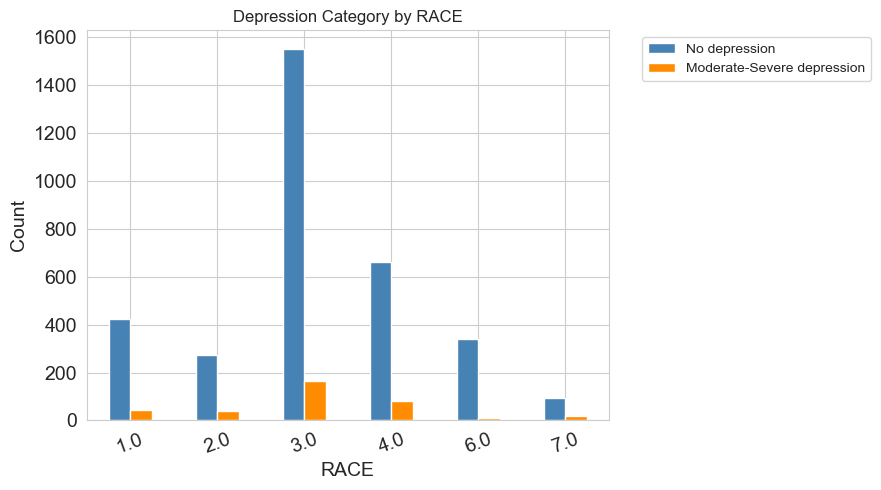

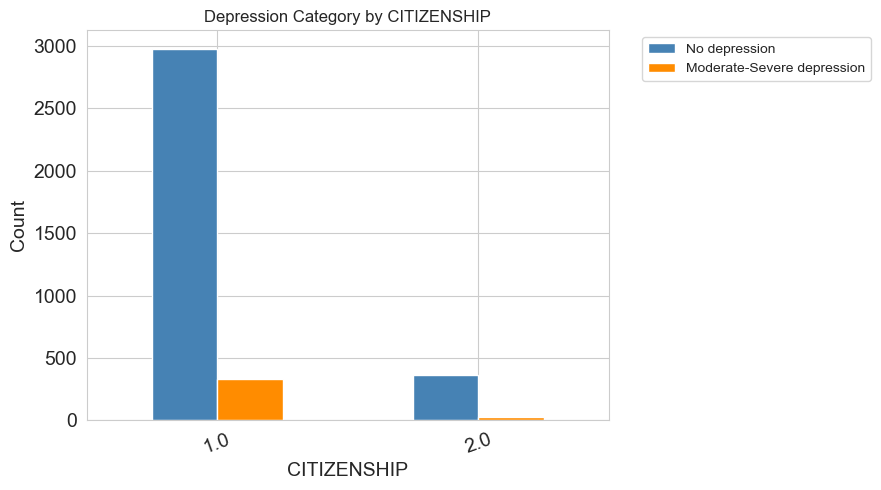

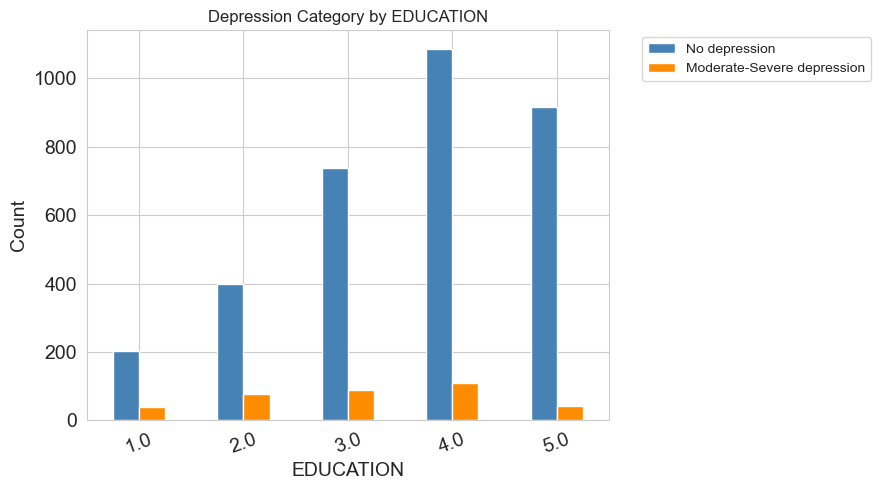

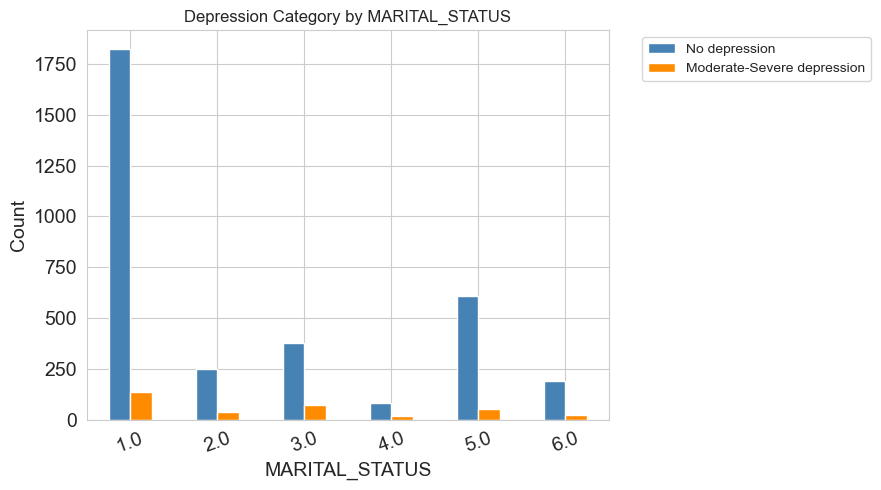

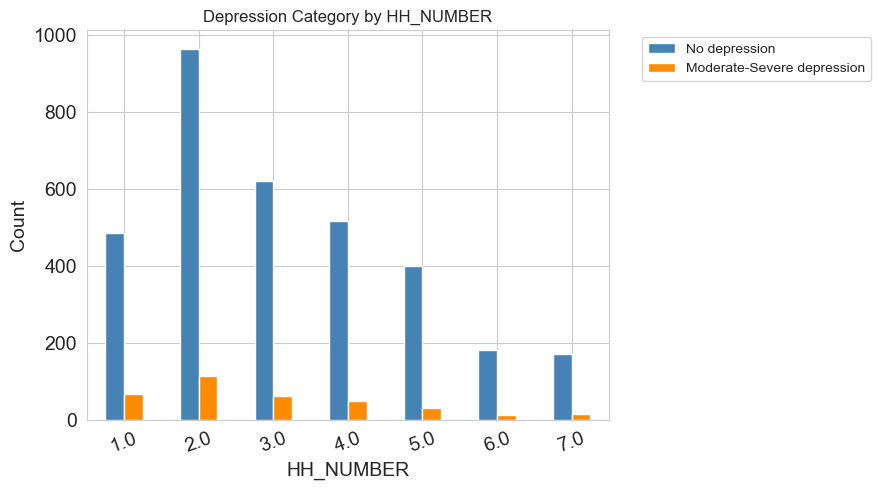

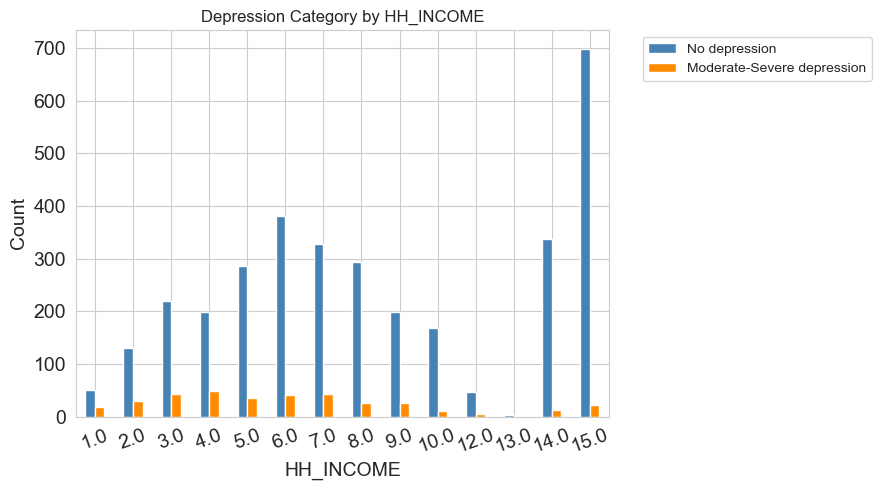

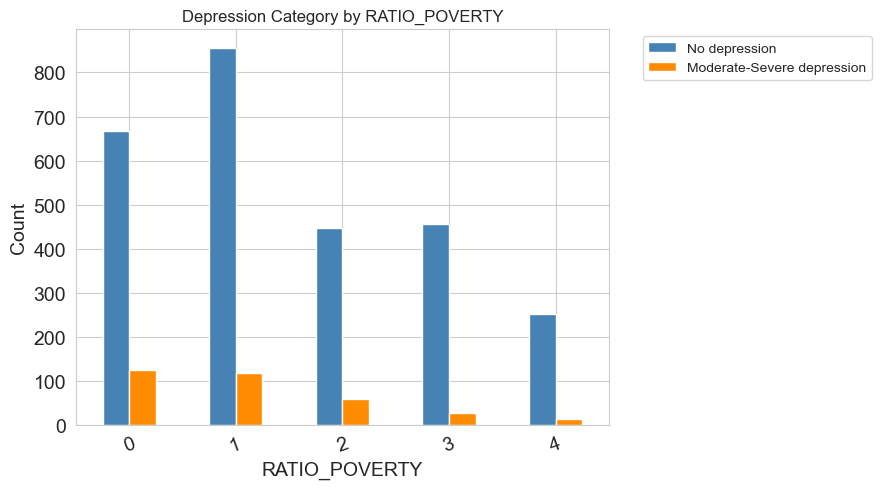

In [58]:
for feat in sensitive_features:
    if feat == 'AGE':
        # Create age groups
        bins = [20, 30, 40, 50, 60, 70, 120]
        labels = ["20-29", "30-39", "40-49", "50-59", "60-69", "70+"]
        df["AGE"] = pd.cut(df["AGE"], bins=bins, labels=labels, right=False)
    if feat == 'RATIO_POVERTY':
        bins=[0,1,2,3,4,5]
        labels=[0,1,2,3,4]
        df["RATIO_POVERTY"] = pd.cut(df["RATIO_POVERTY"], bins=bins, labels=labels, right=False)

    # Compute raw counts
    counts_race = (
        df.groupby(feat)["Depression_Category"]
        .value_counts()
        .unstack(fill_value=0)
    )

    counts_race.columns = ["No depression", "Moderate-Severe depression"]

    # Plot
    counts_race.plot(kind="bar", stacked=False, figsize=(9,5),
                    color=["steelblue", "darkorange"])

    plt.ylabel("Count",fontsize=14)
    plt.xlabel(f"{feat}",fontsize=14)
    plt.title(f"Depression Category by {feat}")

    plt.xticks(
        ticks=range(len(counts_race.index)),
        # labels=['Mexican American','Other Hispanic','Non-Hispanic White',
        #         'Non-Hispanic Black','Non-Hispanic Asian','Other'],
        rotation=20
    ,fontsize=14)
    plt.yticks(fontsize=14)

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [59]:
demo_cols = ["SEX", "AGE", "RACE", "CITIZENSHIP", "EDUCATION",
             "MARITAL_STATUS", "HH_NUMBER", "HH_INCOME", "RATIO_POVERTY"]

outcome = "Depression_Category"

In [60]:
combined_counts = []

for col in demo_cols:
    temp = (
        df.groupby(col)[outcome]
          .value_counts()
          .unstack(fill_value=0)
          .reset_index()
    )
    temp.insert(0, "Feature", col)  # add column name for clarity
    combined_counts.append(temp)

combined_counts_df = pd.concat(combined_counts, ignore_index=True)
combined_counts_df

Depression_Category,Feature,SEX,0,1,AGE,RACE,CITIZENSHIP,EDUCATION,MARITAL_STATUS,HH_NUMBER,HH_INCOME,RATIO_POVERTY
0,SEX,1.0,1637,117,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,SEX,2.0,1704,242,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AGE,NaN,502,34,20-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AGE,NaN,552,49,30-39,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AGE,NaN,597,58,40-49,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,AGE,NaN,541,82,50-59,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,AGE,NaN,585,78,60-69,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,AGE,NaN,564,58,70+,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,RACE,NaN,422,43,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
9,RACE,NaN,273,40,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN
